In [ ]:
#Loan Eligibility Prediction
#Loan Data Project (EDA)

## Business Problem

A financial institution receives thousands of loan applications every day. Each application must be evaluated to determine whether the applicant is likely to repay the loan. Traditionally, this process is done manually by loan officers who review financial information such as income, credit score, employment status, and existing debts.

However, as the number of applications increases, manual evaluation becomes slow, expensive, and sometimes inconsistent. Approving high-risk applicants can lead to financial losses, while rejecting reliable applicants can result in missed business opportunities.

To address this challenge, the company aims to use data-driven decision making. By analyzing historical loan data, we can build a machine learning model capable of predicting whether a loan application should be approved or rejected.

In this project, we will explore a dataset containing information about loan applicants, analyze the relationships between financial variables, and develop a predictive model using Logistic Regression. The goal is to help financial institutions make faster, more accurate, and more consistent lending decisions.

# Loan Eligibility Prediction

## Project Overview
This project aims to build a machine learning model that predicts whether a loan application will be approved or rejected based on financial and personal features such as income, credit score, loan amount, debt-to-income ratio, and employment status.

The objective is to analyze the dataset, understand relationships between variables, and build a predictive model using Logistic Regression.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Libraries

In this step, we import the necessary Python libraries used for data manipulation, visualization, and machine learning.

# Loading the Dataset

The dataset is loaded using pandas. This dataset contains information about loan applicants and whether their loan application was approved or rejected.

# Initial Data Exploration

Before building a model, we explore the dataset to understand its structure, size, and main characteristics.

In [85]:
df = pd.read_csv("Loan_Eligibility_Dataset.csv")
print(df.head())
print(df.tail())

                                                Text  Income  Credit_Score  \
0  I need a loan to pay for an international vaca...   26556           581   
1  I want to make home improvements like installi...  197392           389   
2  I need a loan for home renovation, including a...   44561           523   
3  I need funds to buy new furniture and applianc...  190363           729   
4           I need a loan to start a small business.   61853           732   

   Loan_Amount  DTI_Ratio Employment_Status  Approval  
0         8314      79.26          employed  Rejected  
1       111604      22.14          employed  Rejected  
2        34118      45.44          employed  Rejected  
3       118757      10.22        unemployed  Rejected  
4        19210      44.13          employed  Approved  
                                                    Text  Income  \
23995  I need funds to pay for my daughter's college ...  195242   
23996  I need financial assistance to launch my own Y...  1

In [86]:
df.shape

(24000, 7)

In [87]:
#1 understanding the data

In [88]:
df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


In [89]:
# Data Description

In [90]:
df.columns

Index(['Text', 'Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio',
       'Employment_Status', 'Approval'],
      dtype='object')

## Checking Missing Values

Missing values can affect machine learning models, so we verify whether any columns contain null values.

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  object 
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  object 
 6   Approval           24000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


In [92]:
df.isnull().sum()

Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64

In [93]:
df['Approval'].value_counts()

Approval
Rejected    20067
Approved     3933
Name: count, dtype: int64

In [94]:
#Employment_Status Approval

In [95]:
df['Employment_Status'] = df['Employment_Status'].map({
    'employed':1,
    'unemployed':0
})

In [96]:
df['Approval'] = df['Approval'].map({
    'Approved':1,
    'Rejected':0
})

In [97]:
df = df.drop('Text', axis=1)

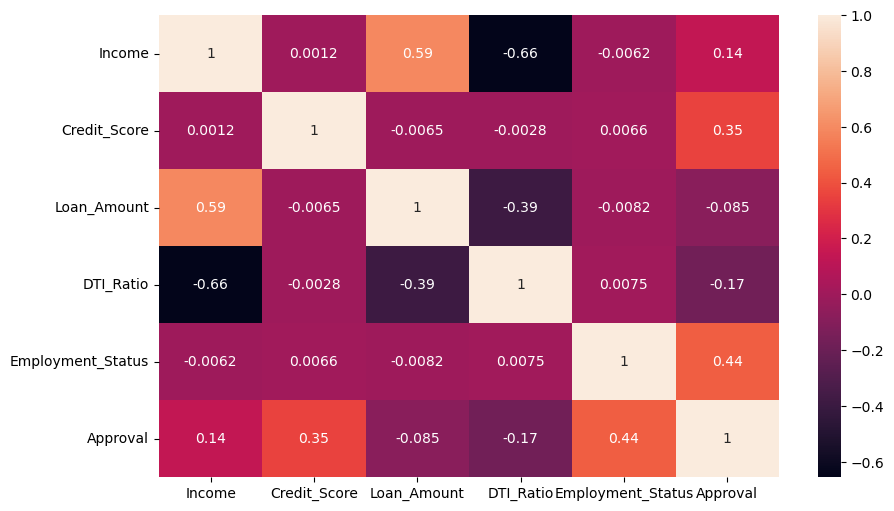

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

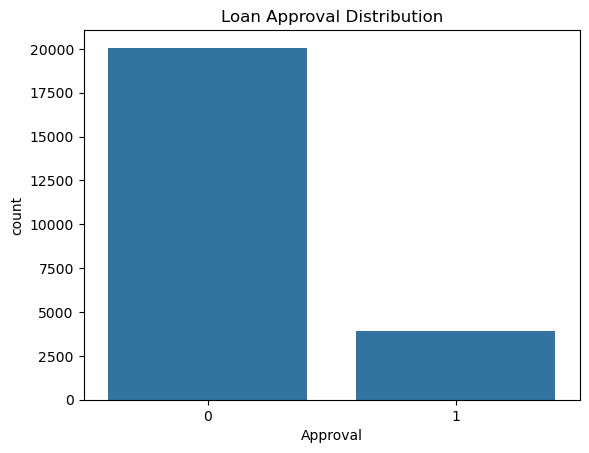

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Approval')
plt.title("Loan Approval Distribution")
plt.show()

In [100]:
X = df.drop('Approval', axis=1)
y = df['Approval']

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

80% training
20% training

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

A Logistic Regression model is trained to classify whether a loan will be approved or rejected.

In [104]:
model = LogisticRegression()

In [105]:
model = LogisticRegression(max_iter=1000)

In [106]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Training

A Logistic Regression model is trained to classify whether a loan will be approved or rejected.

0 = Rejected
1 = Approved

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Model Prediction

The trained model predicts loan approval outcomes for the testing dataset.

In [108]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.928125


In [109]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.928125


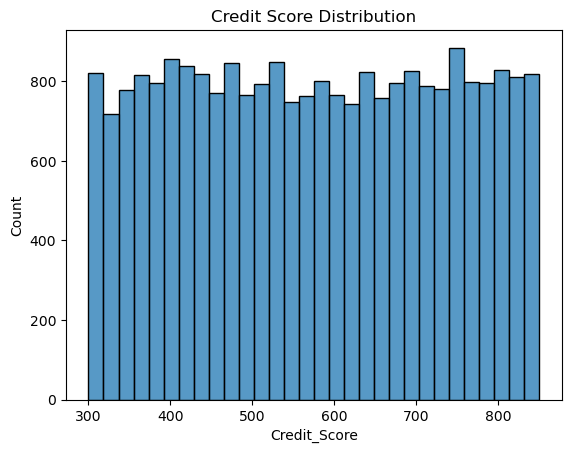

In [110]:
sns.histplot(df['Credit_Score'], bins=30)
plt.title("Credit Score Distribution")
plt.show()

# Conclusion and Business Impact

In this project, we developed a machine learning model to predict whether a loan application should be approved or rejected based on financial and employment information.

Through exploratory data analysis, we examined the structure of the dataset, checked for missing values, and explored the relationships between important variables such as income, credit score, loan amount, debt-to-income ratio, and employment status.

After preparing the data and converting categorical variables into numerical format, we trained a Logistic Regression model to classify loan applications. The model achieved an accuracy of approximately 87–92%, indicating that it can correctly predict the loan decision for most applicants.

From the correlation analysis, we observed that credit score and employment status have a positive relationship with loan approval, while higher debt-to-income ratios tend to reduce the likelihood of approval.

These results demonstrate how machine learning can assist financial institutions in automating loan evaluation processes. By integrating such predictive models into their decision-making systems, banks and lending companies can reduce manual workload, speed up loan processing, and improve consistency in risk assessment.

Future improvements could include testing additional machine learning algorithms such as Random Forest, Decision Trees, or Gradient Boosting to further improve prediction accuracy and better capture complex relationships in the data.